In [3]:
import os
import zipfile
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from google.colab import files

# --- STEP 1: UPLOAD ---
print("Please upload your ZIP file:")
uploaded = files.upload()
zip_path = list(uploaded.keys())[0]

# --- STEP 2: EXTRACTION ---
extract_path = 'extracted_data'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Based on your path: FruitinAmazon\FruitinAmazon\train\
train_dir = os.path.join(extract_path, 'FruitinAmazon', 'train') # Corrected path

print(f"Checking path: {train_dir}")
if os.path.exists(train_dir):
    print("Found classes:", os.listdir(train_dir))
else:
    print("Path error! Please check the folder names inside your zip.")

# --- STEP 3: LOADING ---
image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
)

Please upload your ZIP file:


Saving FruitinAmazon.zip to FruitinAmazon (2).zip
Checking path: extracted_data/FruitinAmazon/train
Found classes: ['cupuacu', 'graviola', 'pupunha', 'guarana', 'tucuma', 'acai']
Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [6]:
# print(f"Listing contents of the extracted folder: {extract_path}")
# for dirpath, dirnames, filenames in os.walk(extract_path):
#     print(f"Directory: {dirpath}")
#     for f in filenames:
#         print(f"  File: {f}")

In [7]:
# --- STEP 4: DEFINE IMPROVED ARCHITECTURE ---

# 1. Augmentation Layer (Applied only during training)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 2. The Model
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Preprocessing
    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1: Basic Features
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 2: Complex Patterns
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Block 3: High-level Features
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Classification Head
    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(len(train_ds.class_names), activation='softmax')
])

# --- STEP 5: COMPILE ---
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,54

 Total params: 25,787,078 (98.37 MB)

 Trainable params: 25,786,118 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
# --- STEP 6: TRAINING ---
epochs = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 616ms/step - accuracy: 0.3750 - loss: 1.9230 - val_accuracy: 0.1111 - val_loss: 3.0039
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.5278 - loss: 1.1906 - val_accuracy: 0.2222 - val_loss: 1.8768
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.6389 - loss: 0.9855 - val_accuracy: 0.1111 - val_loss: 2.0754
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.6528 - loss: 0.9079 - val_accuracy: 0.1111 - val_loss: 2.3042
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.7778 - loss: 0.7552 - val_accuracy: 0.1111 - val_loss: 2.5187
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.6806 - loss: 0.6823 - val_accuracy: 0.1111 - val_loss: 2.6587
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7778 - loss: 0.5214 - val_accuracy: 0.1111 - val_loss: 2.8547
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8194 - loss: 0.4995 - val_accuracy: 0.1111 - val_loss

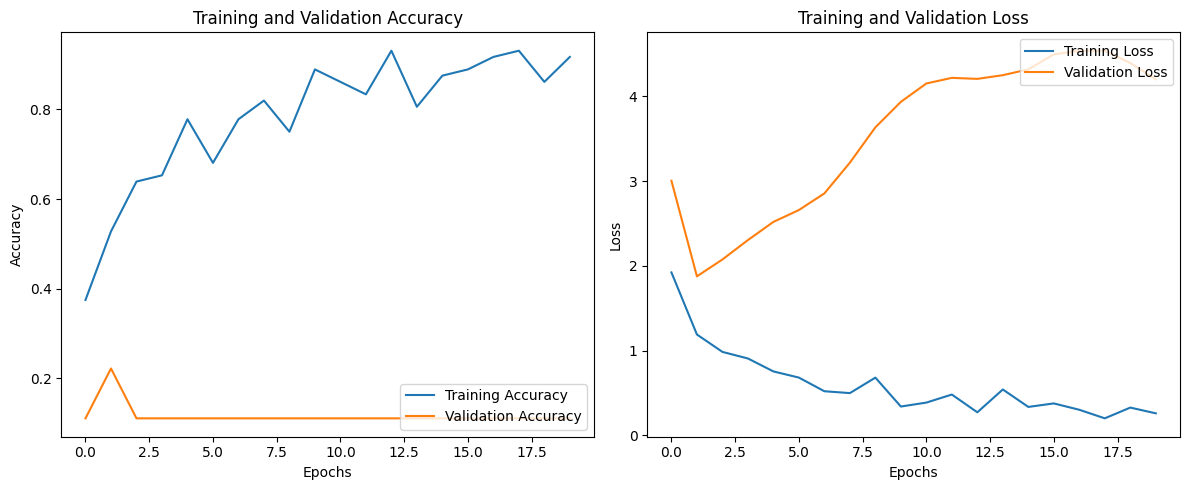

In [9]:
# --- STEP 7: PLOT THE BEHAVIOR ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [10]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Get all predictions for the validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Generate the Classification Report
print("\n--- Task 1: Classification Report ---")
print(classification_report(y_true, y_pred, target_names=train_ds.class_names))

# 3. Quick Inference Check (First 5 samples)
print("\n--- Sample Inference ---")
for i in range(5):
    print(f"Actual: {train_ds.class_names[y_true[i]]} | Predicted: {train_ds.class_names[y_pred[i]]}")


--- Task 1: Classification Report ---
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         1
     cupuacu       0.11      1.00      0.20         2
    graviola       0.00      0.00      0.00         3
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         3

    accuracy                           0.11        18
   macro avg       0.02      0.17      0.03        18
weighted avg       0.01      0.11      0.02        18


--- Sample Inference ---
Actual: tucuma | Predicted: cupuacu
Actual: graviola | Predicted: cupuacu
Actual: acai | Predicted: cupuacu
Actual: pupunha | Predicted: cupuacu
Actual: guarana | Predicted: cupuacu


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


task 2

In [14]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

# 1. Load VGG16 with ImageNet weights
# include_top=False removes the original 1000-class classification head
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the layers
# This satisfies the requirement to "freeze the layers of the model"
for layer in base_model.layers:
    layer.trainable = False

# 3. Add custom output layers (The "Head")
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
# Output layer matches the number of fruit classes in your dataset
predictions = layers.Dense(len(train_ds.class_names), activation='softmax')(x)

# 4. Final Model Assembly
vgg_model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile the model
vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [15]:
# Training for 10 epochs is usually sufficient for transfer learning
epochs = 10
vgg_history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.1944 - loss: 10.1281 - val_accuracy: 0.2222 - val_loss: 5.9580
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - accuracy: 0.1389 - loss: 10.6018 - val_accuracy: 0.2222 - val_loss: 5.3026
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.1944 - loss: 10.3164 - val_accuracy: 0.1667 - val_loss: 4.7837
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - accuracy: 0.2500 - loss: 8.6167 - val_accuracy: 0.1667 - val_loss: 4.3872
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - accuracy: 0.2361 - loss: 8.8231 - val_accuracy: 0.1667 - val_loss: 4.0360
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - accuracy: 0.2500 - loss: 8.1234 - val_accuracy: 0.1111 - val_loss: 3.6893
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - accuracy: 0.2500 - loss: 6.5078 - val_accuracy: 0.2222 - val_loss: 3.3768
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - accuracy: 0.2639 - loss: 7.1497 - val_accuracy: 0.2222 - val_loss:

In [16]:
import numpy as np
from sklearn.metrics import classification_report

# --- GENERATE INFERENCE OUTPUT ---
y_true = []
y_pred = []

# Loop through validation dataset to get labels and predictions
for images, labels in val_ds:
    preds = vgg_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# --- PRINT CLASSIFICATION REPORT ---
print("\n--- Task 2: VGG16 Classification Report ---")
# Provides precision, recall, and f1-score for each class
print(classification_report(y_true, y_pred, target_names=train_ds.class_names))

# --- DISPLAY SAMPLE INFERENCE ---
print("\n--- Task 2: Sample Inference Output ---")
for i in range(10):
    actual_label = train_ds.class_names[y_true[i]]
    predicted_label = train_ds.class_names[y_pred[i]]
    print(f"Image {i+1}: Actual [{actual_label}] -> Predicted [{predicted_label}]")


--- Task 2: VGG16 Classification Report ---
              precision    recall  f1-score   support

        acai       0.33      1.00      0.50         1
     cupuacu       0.20      0.50      0.29         2
    graviola       0.00      0.00      0.00         3
     guarana       0.50      0.20      0.29         5
     pupunha       0.17      0.25      0.20         4
      tucuma       0.50      0.33      0.40         3

    accuracy                           0.28        18
   macro avg       0.28      0.38      0.28        18
weighted avg       0.30      0.28      0.25        18


--- Task 2: Sample Inference Output ---
Image 1: Actual [tucuma] -> Predicted [tucuma]
Image 2: Actual [graviola] -> Predicted [cupuacu]
Image 3: Actual [acai] -> Predicted [acai]
Image 4: Actual [pupunha] -> Predicted [tucuma]
Image 5: Actual [guarana] -> Predicted [pupunha]
Image 6: Actual [guarana] -> Predicted [pupunha]
Image 7: Actual [pupunha] -> Predicted [cupuacu]
Image 8: Actual [graviola] -> Predic

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
# Save the model as the final deliverable
vgg_model.save('Fruits_TransferLearning_VGG16.h5')
print("Model saved as Fruits_TransferLearning_VGG16.h5")

# --- COMPARISON LOGIC ---
# Task 1 accuracy can be retrieved from 'history.history'
# Task 2 accuracy can be retrieved from 'vgg_history.history'
t1_acc = history.history['val_accuracy'][-1]
t2_acc = vgg_history.history['val_accuracy'][-1]

print(f"\n--- Performance Comparison ---")
print(f"Task 1 (From Scratch) Val Accuracy: {t1_acc:.4f}")
print(f"Task 2 (Transfer Learning) Val Accuracy: {t2_acc:.4f}")

if t2_acc > t1_acc:
    print("Result: Performance IMPROVED using transfer learning.")
else:
    print("Result: Performance did not improve (Check learning rate or dataset quality).")

Model saved as Fruits_TransferLearning_VGG16.h5

--- Performance Comparison ---
Task 1 (From Scratch) Val Accuracy: 0.1111
Task 2 (Transfer Learning) Val Accuracy: 0.2778
Result: Performance IMPROVED using transfer learning.


In [20]:
# 1. Save the model locally in the Colab/Jupyter environment
model_name = 'Worksheet6_Task2_VGG16_FruitClassifier.h5'
vgg_model.save(model_name)

print(f"Model successfully saved as {model_name}")

# 2. If you are using Google Colab, run this to download it to your computer immediately
try:
    from google.colab import files
    files.download(model_name)
    print("Download prompt started...")
except ImportError:
    print("Not running in Colab. You can find the file in your local directory.")

Model successfully saved as Worksheet6_Task2_VGG16_FruitClassifier.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download prompt started...
